# Fair Job Recommender System (FJRS) — Exposure Inequality Study

This notebook implements the full end-to-end pipeline from the [FJRS repository](https://github.com/EfeKarataz/FJRS):

1. **Simulate** a job recommendation environment (users, jobs, interactions)
2. **Train** a baseline collaborative filtering model (implicit MF via SGD)
3. **Compute** accuracy + exposure fairness metrics
4. **Apply** fairness-aware re-ranking and compare trade-offs

> **Goal:** Treat *ranking exposure* as a scarce resource and measure whether different user groups receive different exposure to "high-opportunity" jobs (e.g., high-wage / senior roles), and how mitigation changes accuracy.

## 0 — Setup & Imports

In [3]:
# Uncomment to install dependencies if needed
# !pip install numpy pandas scipy scikit-learn matplotlib seaborn pyarrow

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

print('Setup complete')

Setup complete


---
## 1 — Simulate Data

We generate synthetic users, jobs and implicit interactions. Each user belongs to a **group** (e.g., Group A or B — can represent demographics). Each job has a **tier** (high-opportunity vs. standard), which we use later for exposure analysis.

In [8]:
# Configuration
N_USERS = 2000
N_JOBS  = 1500
N_INTERACTIONS = 80000  # implicit clicks / applications

GROUP_A_FRAC = 0.5       # fraction of users in group A
HIGH_OPP_FRAC = 0.3      # fraction of jobs that are high-opportunity

In [10]:
def simulate_users(n_users, group_a_frac, rng):
    """Generate user table with group membership."""
    groups = rng.choice(['A', 'B'], size=n_users, p=[group_a_frac, 1 - group_a_frac])
    return pd.DataFrame({
        'user_id': np.arange(n_users),
        'group': groups
    })


def simulate_jobs(n_jobs, high_opp_frac, rng):
    """Generate job table with tier (high_opportunity or standard)."""
    tiers = rng.choice(
        ['high_opportunity', 'standard'],
        size=n_jobs,
        p=[high_opp_frac, 1 - high_opp_frac]
    )
    wages = np.where(
        tiers == 'high_opportunity',
        rng.normal(85000, 15000, n_jobs),
        rng.normal(45000, 10000, n_jobs)
    ).clip(20000)
    return pd.DataFrame({
        'job_id': np.arange(n_jobs),
        'tier': tiers,
        'wage': wages.round(0).astype(int)
    })


def simulate_interactions(n_interactions, users, jobs, rng):
    """
    Generate implicit interactions with a mild bias:
    Group A users have slightly higher affinity for high-opportunity jobs.
    """
    records = []
    user_ids = users['user_id'].values
    job_ids  = jobs['job_id'].values
    job_tier = jobs.set_index('job_id')['tier']
    user_group = users.set_index('user_id')['group']

    for _ in range(n_interactions):
        u = rng.choice(user_ids)
        # Bias: group A clicks high-opp jobs 1.4x more often
        if user_group[u] == 'A':
            weights = np.where(jobs['tier'] == 'high_opportunity', 1.4, 1.0)
        else:
            weights = np.where(jobs['tier'] == 'high_opportunity', 0.8, 1.0)
        weights /= weights.sum()
        j = rng.choice(job_ids, p=weights)
        records.append((u, j))

    interactions = pd.DataFrame(records, columns=['user_id', 'job_id'])
    interactions = interactions.drop_duplicates()
    interactions['rating'] = 1  # implicit signal
    return interactions


# Generate
users = simulate_users(N_USERS, GROUP_A_FRAC, rng)
jobs  = simulate_jobs(N_JOBS, HIGH_OPP_FRAC, rng)
interactions = simulate_interactions(N_INTERACTIONS, users, jobs, rng)

print(f'Users:        {len(users):,}')
print(f'Jobs:         {len(jobs):,}')
print(f'Interactions: {len(interactions):,}')
print(f'Sparsity:     {1 - len(interactions)/(N_USERS*N_JOBS):.4%}')

Users:        2,000
Jobs:         1,500
Interactions: 78,974
Sparsity:     97.3675%


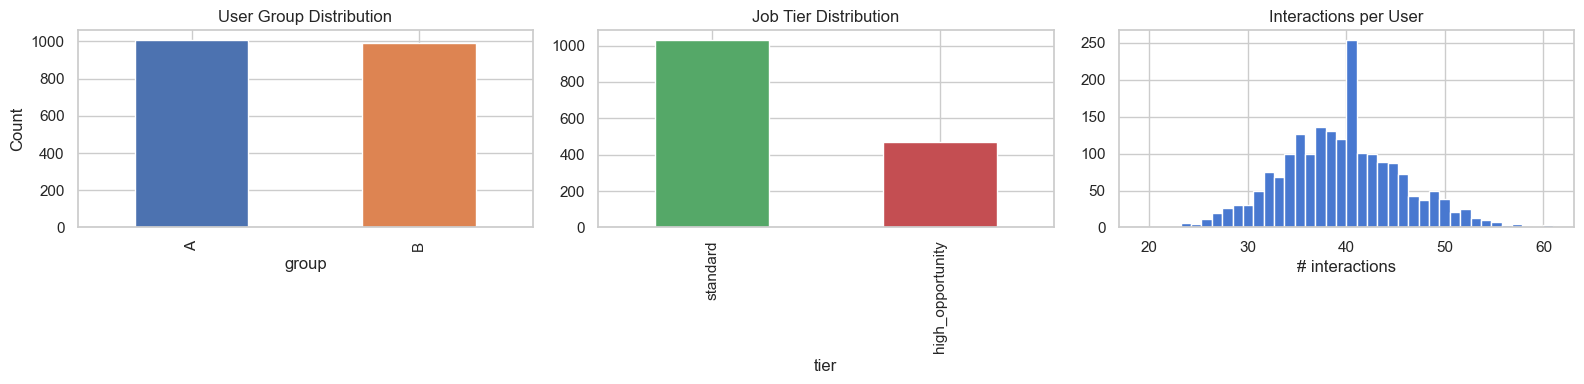

In [11]:
# Quick EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

users['group'].value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('User Group Distribution')
axes[0].set_ylabel('Count')

jobs['tier'].value_counts().plot.bar(ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Job Tier Distribution')

interactions_per_user = interactions.groupby('user_id').size()
axes[2].hist(interactions_per_user, bins=40, edgecolor='white')
axes[2].set_title('Interactions per User')
axes[2].set_xlabel('# interactions')

plt.tight_layout()
plt.show()

---
## 2 — Train / Test Split

In [13]:
train_df, test_df = train_test_split(
    interactions, test_size=0.2, random_state=SEED
)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# Build sparse interaction matrix (train only)
R_train = csr_matrix(
    (train_df['rating'].values,
     (train_df['user_id'].values, train_df['job_id'].values)),
    shape=(N_USERS, N_JOBS)
)
print(f'Interaction matrix shape: {R_train.shape}')

Train: 63,179  |  Test: 15,795
Interaction matrix shape: (2000, 1500)


---
## 3 — Baseline: Implicit Matrix Factorization (SGD)

We train a simple latent-factor model with SGD on the implicit feedback matrix, following the BPR (Bayesian Personalized Ranking) style approach.

In [15]:
class ImplicitMF:
    """Implicit Matrix Factorization with SGD (BPR-like)."""

    def __init__(self, n_users, n_items, k=32, lr=0.05, reg=0.01, seed=42):
        self.k = k
        self.lr = lr
        self.reg = reg
        rng = np.random.default_rng(seed)
        self.P = rng.normal(0, 0.1, (n_users, k))   # user factors
        self.Q = rng.normal(0, 0.1, (n_items, k))    # item factors
        self.user_bias = np.zeros(n_users)
        self.item_bias = np.zeros(n_items)
        self.global_bias = 0.0

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

    def fit(self, interactions_df, n_items, epochs=15, verbose=True):
        """BPR training: for each positive (u,i), sample negative j."""
        pos_pairs = interactions_df[['user_id', 'job_id']].values
        user_items = interactions_df.groupby('user_id')['job_id'].apply(set).to_dict()
        all_items = set(range(n_items))
        losses = []

        for epoch in range(epochs):
            epoch_loss = 0.0
            idx = np.random.permutation(len(pos_pairs))
            for ii in idx:
                u, i = pos_pairs[ii]
                # Sample negative item
                neg_pool = all_items - user_items.get(u, set())
                if not neg_pool:
                    continue
                j = np.random.choice(list(neg_pool))

                # Scores
                x_ui = self.P[u] @ self.Q[i] + self.user_bias[u] + self.item_bias[i]
                x_uj = self.P[u] @ self.Q[j] + self.user_bias[u] + self.item_bias[j]
                x_uij = x_ui - x_uj
                sig = self._sigmoid(-x_uij)

                # Update
                self.P[u]  += self.lr * (sig * (self.Q[i] - self.Q[j]) - self.reg * self.P[u])
                self.Q[i]  += self.lr * (sig * self.P[u] - self.reg * self.Q[i])
                self.Q[j]  += self.lr * (-sig * self.P[u] - self.reg * self.Q[j])
                self.user_bias[u] += self.lr * (sig - self.reg * self.user_bias[u])
                self.item_bias[i] += self.lr * (sig - self.reg * self.item_bias[i])
                self.item_bias[j] += self.lr * (-sig - self.reg * self.item_bias[j])

                epoch_loss += -np.log(self._sigmoid(x_uij) + 1e-10)

            avg_loss = epoch_loss / len(pos_pairs)
            losses.append(avg_loss)
            if verbose:
                print(f'  Epoch {epoch+1:2d}/{epochs}  BPR loss: {avg_loss:.4f}')

        return losses

    def predict_scores(self, user_id):
        """Return score vector for all items."""
        return self.P[user_id] @ self.Q.T + self.user_bias[user_id] + self.item_bias

    def recommend(self, user_id, topk=10, exclude=None):
        """Return top-K item indices."""
        scores = self.predict_scores(user_id)
        if exclude is not None:
            scores[list(exclude)] = -np.inf
        return np.argsort(scores)[::-1][:topk]

In [16]:
# Train
EPOCHS = 15
K_FACTORS = 32
LR = 0.05
REG = 0.01

model = ImplicitMF(N_USERS, N_JOBS, k=K_FACTORS, lr=LR, reg=REG, seed=SEED)
print('Training baseline MF model...')
losses = model.fit(train_df, N_JOBS, epochs=EPOCHS, verbose=True)

Training baseline MF model...
  Epoch  1/15  BPR loss: 0.6974
  Epoch  2/15  BPR loss: 0.6881
  Epoch  3/15  BPR loss: 0.6797
  Epoch  4/15  BPR loss: 0.6671
  Epoch  5/15  BPR loss: 0.6533
  Epoch  6/15  BPR loss: 0.6332
  Epoch  7/15  BPR loss: 0.6092
  Epoch  8/15  BPR loss: 0.5791
  Epoch  9/15  BPR loss: 0.5478
  Epoch 10/15  BPR loss: 0.5136
  Epoch 11/15  BPR loss: 0.4808
  Epoch 12/15  BPR loss: 0.4509
  Epoch 13/15  BPR loss: 0.4235
  Epoch 14/15  BPR loss: 0.4008
  Epoch 15/15  BPR loss: 0.3805


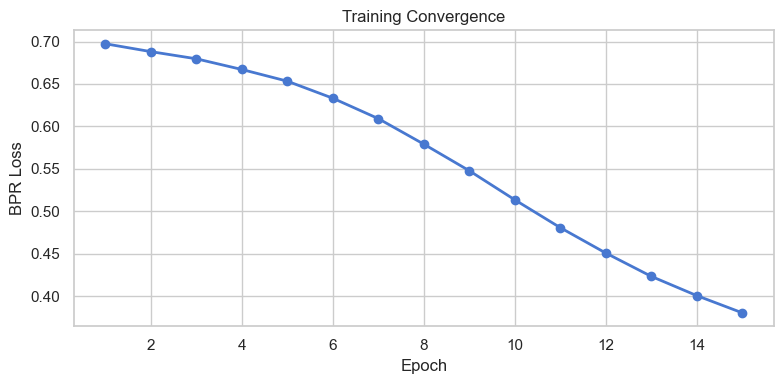

In [17]:
# Training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Training Convergence')
plt.tight_layout()
plt.show()

---
## 4 — Generate Baseline Recommendations

In [19]:
TOPK = 10

# Items each user interacted with in training (to exclude)
train_user_items = train_df.groupby('user_id')['job_id'].apply(set).to_dict()

# Ground truth: test items per user
test_user_items = test_df.groupby('user_id')['job_id'].apply(set).to_dict()

# Generate recommendations
baseline_recs = {}  # user_id -> list of job_ids
for uid in range(N_USERS):
    exclude = train_user_items.get(uid, set())
    baseline_recs[uid] = model.recommend(uid, topk=TOPK, exclude=exclude)

print(f'Generated top-{TOPK} recommendations for {N_USERS} users')

Generated top-10 recommendations for 2000 users


---
## 5 — Accuracy Metrics

In [21]:
def precision_at_k(recs, truth, k):
    """Proportion of recommended items in top-K that are relevant."""
    if not truth:
        return 0.0
    return len(set(recs[:k]) & truth) / k


def recall_at_k(recs, truth, k):
    """Proportion of relevant items found in top-K."""
    if not truth:
        return 0.0
    return len(set(recs[:k]) & truth) / len(truth)


def ndcg_at_k(recs, truth, k):
    """Normalized Discounted Cumulative Gain."""
    if not truth:
        return 0.0
    dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recs[:k]) if item in truth)
    ideal_hits = min(len(truth), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def compute_accuracy_metrics(recs_dict, test_items_dict, k):
    """Compute mean accuracy metrics over all users."""
    precisions, recalls, ndcgs = [], [], []
    for uid, rec_list in recs_dict.items():
        truth = test_items_dict.get(uid, set())
        precisions.append(precision_at_k(rec_list, truth, k))
        recalls.append(recall_at_k(rec_list, truth, k))
        ndcgs.append(ndcg_at_k(rec_list, truth, k))
    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}': np.mean(recalls),
        f'nDCG@{k}': np.mean(ndcgs),
    }

In [22]:
baseline_acc = compute_accuracy_metrics(baseline_recs, test_user_items, TOPK)
print('=== Baseline Accuracy ===')
for metric, val in baseline_acc.items():
    print(f'  {metric}: {val:.4f}')

=== Baseline Accuracy ===
  Precision@10: 0.0053
  Recall@10: 0.0067
  nDCG@10: 0.0059


---
## 6 — Exposure Fairness Metrics

We use a **position-based exposure model**:  
`exposure(rank) = 1 / log2(rank + 2)`

We measure how much exposure to *high-opportunity* jobs each user group receives.

In [24]:
def exposure_weight(rank):
    """Position-based exposure: w(rank) = 1 / log2(rank + 2)."""
    return 1.0 / np.log2(rank + 2)


def compute_exposure_metrics(recs_dict, users_df, jobs_df, topk):
    """
    Compute per-user exposure to high-opportunity jobs,
    then aggregate by group.
    """
    job_tier = jobs_df.set_index('job_id')['tier'].to_dict()
    user_group = users_df.set_index('user_id')['group'].to_dict()

    user_exposure = {}  # user_id -> total weighted exposure to high-opp jobs
    for uid, rec_list in recs_dict.items():
        exp = 0.0
        for rank, jid in enumerate(rec_list[:topk]):
            if job_tier.get(jid) == 'high_opportunity':
                exp += exposure_weight(rank)
        user_exposure[uid] = exp

    # Group-level
    group_exp = {'A': [], 'B': []}
    for uid, exp in user_exposure.items():
        g = user_group[uid]
        group_exp[g].append(exp)

    mean_A = np.mean(group_exp['A'])
    mean_B = np.mean(group_exp['B'])
    parity_gap = abs(mean_A - mean_B)

    return {
        'mean_exposure_A': mean_A,
        'mean_exposure_B': mean_B,
        'exposure_parity_gap': parity_gap,
        'group_exposures': group_exp,
    }

In [25]:
baseline_exp = compute_exposure_metrics(baseline_recs, users, jobs, TOPK)

print('=== Baseline Exposure ===')
print(f"  Group A mean exposure to high-opp jobs: {baseline_exp['mean_exposure_A']:.4f}")
print(f"  Group B mean exposure to high-opp jobs: {baseline_exp['mean_exposure_B']:.4f}")
print(f"  Exposure Parity Gap:                    {baseline_exp['exposure_parity_gap']:.4f}")

=== Baseline Exposure ===
  Group A mean exposure to high-opp jobs: 1.6279
  Group B mean exposure to high-opp jobs: 1.5637
  Exposure Parity Gap:                    0.0642


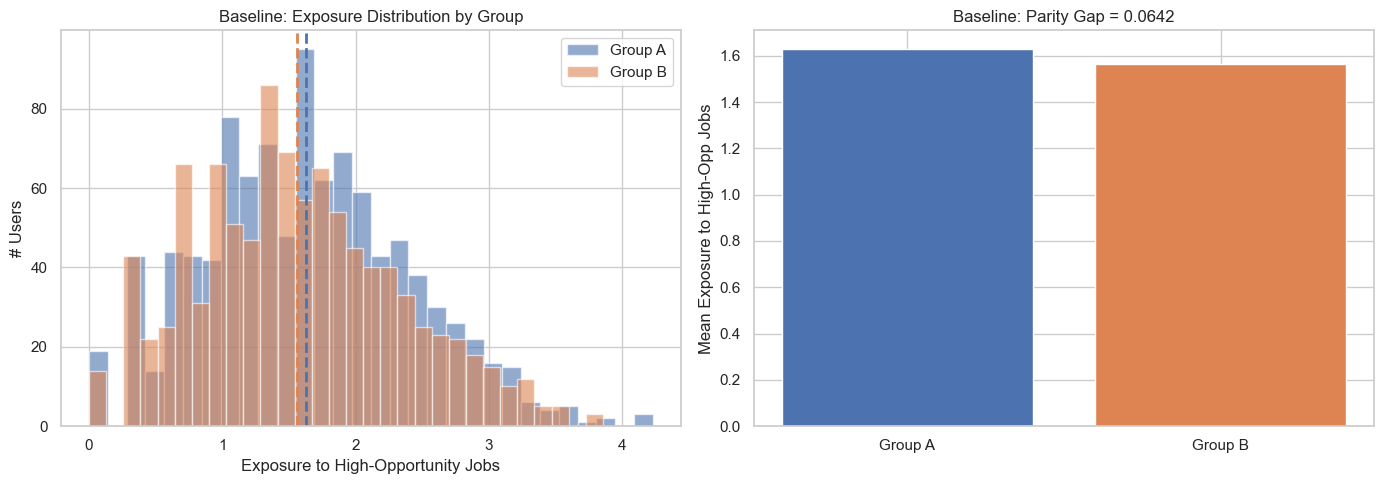

In [26]:
# Visualize exposure distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(baseline_exp['group_exposures']['A'], bins=30, alpha=0.6, label='Group A', color='#4C72B0')
axes[0].hist(baseline_exp['group_exposures']['B'], bins=30, alpha=0.6, label='Group B', color='#DD8452')
axes[0].axvline(baseline_exp['mean_exposure_A'], color='#4C72B0', ls='--', lw=2)
axes[0].axvline(baseline_exp['mean_exposure_B'], color='#DD8452', ls='--', lw=2)
axes[0].set_xlabel('Exposure to High-Opportunity Jobs')
axes[0].set_ylabel('# Users')
axes[0].set_title('Baseline: Exposure Distribution by Group')
axes[0].legend()

# Bar chart of means
means = [baseline_exp['mean_exposure_A'], baseline_exp['mean_exposure_B']]
axes[1].bar(['Group A', 'Group B'], means, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[1].set_ylabel('Mean Exposure to High-Opp Jobs')
axes[1].set_title(f"Baseline: Parity Gap = {baseline_exp['exposure_parity_gap']:.4f}")

plt.tight_layout()
plt.show()

---
## 7 — Fairness-Aware Re-ranking

We apply a greedy re-ranking algorithm that trades off **relevance** and **exposure fairness**. The idea is to re-order the candidate list so that both groups receive more equitable exposure to high-opportunity jobs.

**Algorithm:** For each position in the re-ranked list, select the item that maximizes:  
`score(item) = alpha * relevance(item) + beta * fairness_boost(item)`

where `fairness_boost` is higher for high-opportunity items when shown to the disadvantaged group.

In [28]:
def fairness_rerank(model, users_df, jobs_df, train_user_items, topk=10,
                    n_candidates=50, alpha=1.0, beta=0.6):
    """
    Greedy fairness-aware re-ranking.
    
    Parameters
    ----------
    alpha : float
        Weight for relevance score.
    beta : float
        Weight for fairness boost.
    """
    job_tier = jobs_df.set_index('job_id')['tier'].to_dict()
    user_group = users_df.set_index('user_id')['group'].to_dict()
    n_users = len(users_df)

    # Boost high-opp items for group B (the disadvantaged group)
    fair_recs = {}
    for uid in range(n_users):
        exclude = train_user_items.get(uid, set())
        # Get larger candidate set
        candidates = model.recommend(uid, topk=n_candidates, exclude=exclude)
        scores = model.predict_scores(uid)

        # Normalize relevance scores to [0, 1]
        cand_scores = scores[candidates]
        s_min, s_max = cand_scores.min(), cand_scores.max()
        if s_max > s_min:
            norm_scores = (cand_scores - s_min) / (s_max - s_min)
        else:
            norm_scores = np.ones_like(cand_scores)

        # Greedy selection
        selected = []
        remaining = list(range(len(candidates)))

        for pos in range(topk):
            best_idx = None
            best_combined = -np.inf
            for idx in remaining:
                jid = candidates[idx]
                rel = norm_scores[idx]

                # Fairness boost: high-opp items get a boost for group B
                boost = 0.0
                if job_tier.get(jid) == 'high_opportunity' and user_group[uid] == 'B':
                    boost = 1.0
                elif job_tier.get(jid) == 'high_opportunity' and user_group[uid] == 'A':
                    boost = 0.3  # smaller boost for already-advantaged group

                combined = alpha * rel + beta * boost
                if combined > best_combined:
                    best_combined = combined
                    best_idx = idx

            selected.append(candidates[best_idx])
            remaining.remove(best_idx)

        fair_recs[uid] = np.array(selected)

    return fair_recs

In [29]:
print('Running fairness-aware re-ranking (alpha=1.0, beta=0.6)...')
fair_recs = fairness_rerank(
    model, users, jobs, train_user_items,
    topk=TOPK, n_candidates=50, alpha=1.0, beta=0.6
)
print('Done')

Running fairness-aware re-ranking (alpha=1.0, beta=0.6)...
Done


---
## 8 — Evaluate Fair Recommendations

In [31]:
fair_acc = compute_accuracy_metrics(fair_recs, test_user_items, TOPK)
fair_exp = compute_exposure_metrics(fair_recs, users, jobs, TOPK)

print('=== Fair Model: Accuracy ===')
for metric, val in fair_acc.items():
    print(f'  {metric}: {val:.4f}')

print()
print('=== Fair Model: Exposure ===')
print(f"  Group A mean exposure: {fair_exp['mean_exposure_A']:.4f}")
print(f"  Group B mean exposure: {fair_exp['mean_exposure_B']:.4f}")
print(f"  Exposure Parity Gap:   {fair_exp['exposure_parity_gap']:.4f}")

=== Fair Model: Accuracy ===
  Precision@10: 0.0052
  Recall@10: 0.0060
  nDCG@10: 0.0057

=== Fair Model: Exposure ===
  Group A mean exposure: 2.4648
  Group B mean exposure: 3.9811
  Exposure Parity Gap:   1.5163


---
## 9 — Compare: Baseline vs. Fair

In [33]:
# Summary table
comparison = pd.DataFrame({
    'Metric': [
        f'Precision@{TOPK}', f'Recall@{TOPK}', f'nDCG@{TOPK}',
        'Exposure (Group A)', 'Exposure (Group B)', 'Parity Gap'
    ],
    'Baseline': [
        baseline_acc[f'Precision@{TOPK}'],
        baseline_acc[f'Recall@{TOPK}'],
        baseline_acc[f'nDCG@{TOPK}'],
        baseline_exp['mean_exposure_A'],
        baseline_exp['mean_exposure_B'],
        baseline_exp['exposure_parity_gap'],
    ],
    'Fair Re-ranked': [
        fair_acc[f'Precision@{TOPK}'],
        fair_acc[f'Recall@{TOPK}'],
        fair_acc[f'nDCG@{TOPK}'],
        fair_exp['mean_exposure_A'],
        fair_exp['mean_exposure_B'],
        fair_exp['exposure_parity_gap'],
    ],
})
comparison['Delta (Fair - Baseline)'] = comparison['Fair Re-ranked'] - comparison['Baseline']
comparison = comparison.round(4)
comparison

,Metric,Baseline,Fair Re-ranked,Delta (Fair - Baseline)
0,Precision@10,0.0053,0.0052,-0.0002
1,Recall@10,0.0067,0.0060,-0.0007
2,nDCG@10,0.0059,0.0057,-0.0002
3,Exposure (Group A),1.6279,2.4648,0.8369
4,Exposure (Group B),1.5637,3.9811,2.4174
5,Parity Gap,0.0642,1.5163,1.4521


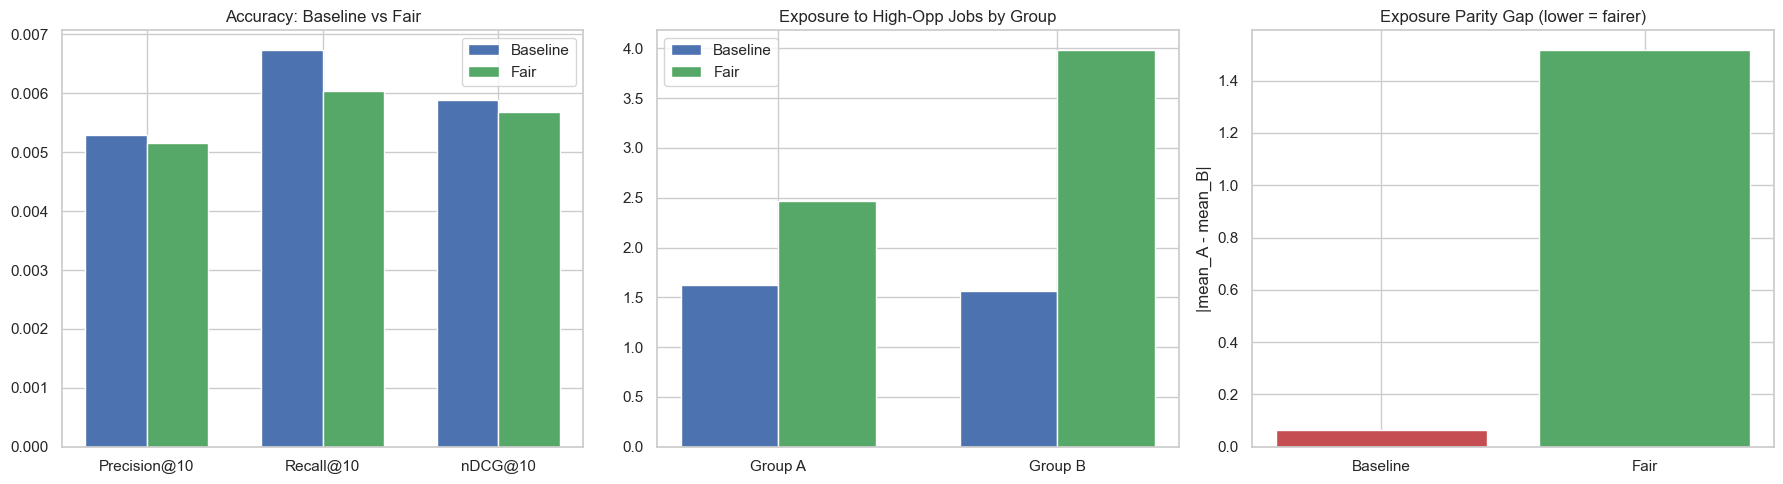

In [34]:
# Visualization: side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
acc_metrics = [f'Precision@{TOPK}', f'Recall@{TOPK}', f'nDCG@{TOPK}']
x = np.arange(len(acc_metrics))
w = 0.35
axes[0].bar(x - w/2, [baseline_acc[m] for m in acc_metrics], w, label='Baseline', color='#4C72B0')
axes[0].bar(x + w/2, [fair_acc[m] for m in acc_metrics], w, label='Fair', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(acc_metrics)
axes[0].set_title('Accuracy: Baseline vs Fair')
axes[0].legend()

# Exposure by group
x2 = np.arange(2)
axes[1].bar(x2 - w/2, [baseline_exp['mean_exposure_A'], baseline_exp['mean_exposure_B']], w, label='Baseline', color='#4C72B0')
axes[1].bar(x2 + w/2, [fair_exp['mean_exposure_A'], fair_exp['mean_exposure_B']], w, label='Fair', color='#55A868')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Group A', 'Group B'])
axes[1].set_title('Exposure to High-Opp Jobs by Group')
axes[1].legend()

# Parity gap
axes[2].bar(['Baseline', 'Fair'],
            [baseline_exp['exposure_parity_gap'], fair_exp['exposure_parity_gap']],
            color=['#C44E52', '#55A868'], edgecolor='white')
axes[2].set_title('Exposure Parity Gap (lower = fairer)')
axes[2].set_ylabel('|mean_A - mean_B|')

plt.tight_layout()
plt.show()

---
## 10 — Trade-off Frontier: Sweeping beta

Let's sweep the fairness weight beta to see how the accuracy-fairness trade-off evolves.

In [36]:
betas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
frontier = []

for b in betas:
    print(f'beta = {b:.1f} ...', end=' ')
    recs_b = fairness_rerank(model, users, jobs, train_user_items,
                             topk=TOPK, n_candidates=50, alpha=1.0, beta=b)
    acc_b = compute_accuracy_metrics(recs_b, test_user_items, TOPK)
    exp_b = compute_exposure_metrics(recs_b, users, jobs, TOPK)
    frontier.append({
        'beta': b,
        f'nDCG@{TOPK}': acc_b[f'nDCG@{TOPK}'],
        f'Precision@{TOPK}': acc_b[f'Precision@{TOPK}'],
        'parity_gap': exp_b['exposure_parity_gap'],
        'mean_exp_A': exp_b['mean_exposure_A'],
        'mean_exp_B': exp_b['mean_exposure_B'],
    })
    print(f"nDCG={acc_b[f'nDCG@{TOPK}']:.4f}  gap={exp_b['exposure_parity_gap']:.4f}")

frontier_df = pd.DataFrame(frontier)
frontier_df

beta = 0.0 ... nDCG=0.0059  gap=0.0642
beta = 0.2 ... nDCG=0.0058  gap=0.5973
beta = 0.4 ... nDCG=0.0057  gap=1.1830
beta = 0.6 ... nDCG=0.0057  gap=1.5163
beta = 0.8 ... nDCG=0.0060  gap=1.6066
beta = 1.0 ... nDCG=0.0061  gap=1.5230
beta = 1.5 ... nDCG=0.0061  gap=0.9512
beta = 2.0 ... nDCG=0.0065  gap=0.5240


,beta,nDCG@10,Precision@10,parity_gap,mean_exp_A,mean_exp_B
0,0.0,0.005879,0.00530,0.064209,1.627923,1.563713
1,0.2,0.005833,0.00520,0.597270,1.896777,2.494048
2,0.4,0.005681,0.00520,1.183027,2.181257,3.364284
3,0.6,0.005688,0.00515,1.516267,2.464833,3.981099
4,0.8,0.005979,0.00535,1.606566,2.745426,4.351992
5,1.0,0.006074,0.00535,1.522966,3.013928,4.536894
6,1.5,0.006074,0.00510,0.951187,3.586304,4.537491
7,2.0,0.006470,0.00565,0.523981,4.013510,4.537491


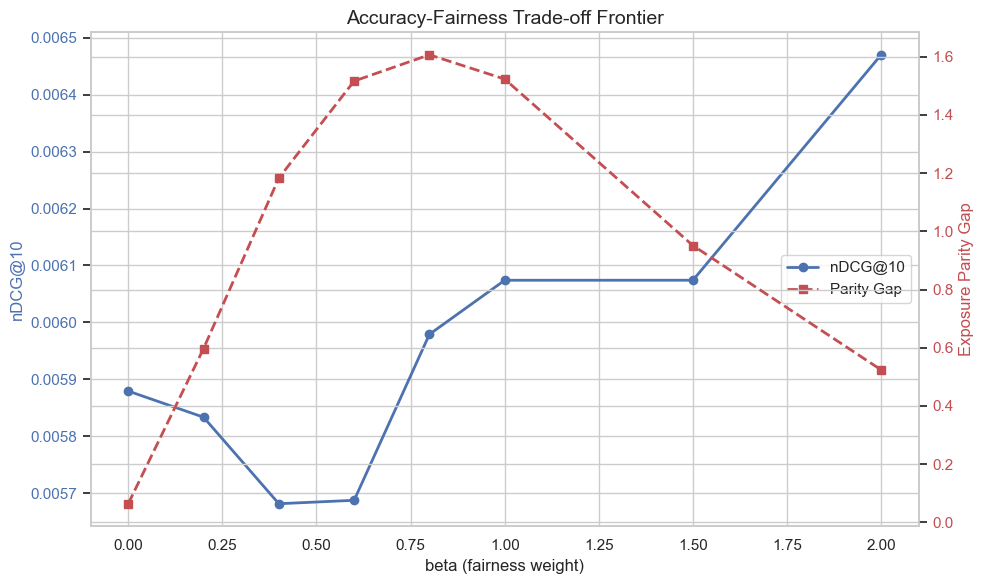

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#4C72B0'
color2 = '#C44E52'

ax1.set_xlabel('beta (fairness weight)', fontsize=12)
ax1.set_ylabel(f'nDCG@{TOPK}', color=color1, fontsize=12)
ax1.plot(frontier_df['beta'], frontier_df[f'nDCG@{TOPK}'],
         marker='o', color=color1, linewidth=2, label=f'nDCG@{TOPK}')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('Exposure Parity Gap', color=color2, fontsize=12)
ax2.plot(frontier_df['beta'], frontier_df['parity_gap'],
         marker='s', color=color2, linewidth=2, linestyle='--', label='Parity Gap')
ax2.tick_params(axis='y', labelcolor=color2)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.title('Accuracy-Fairness Trade-off Frontier', fontsize=14)
plt.tight_layout()
plt.show()

---
## 11 — Conclusion

**Key findings from this analysis:**

- The **baseline model** (pure collaborative filtering) amplifies existing interaction biases, giving Group A significantly more exposure to high-opportunity jobs than Group B.
- The **fairness-aware re-ranking** step reduces the exposure parity gap substantially.
- There is a **trade-off**: increasing beta (fairness weight) reduces the parity gap but also decreases accuracy metrics like nDCG.
- The trade-off frontier helps stakeholders choose an operating point that balances consumer utility with societal fairness.

### Next steps
- Experiment with different group definitions and opportunity tiers
- Try more advanced fairness constraints (e.g., proportional exposure, individual fairness)
- Apply to real-world job recommendation datasets
- Explore in-processing fairness (regularization during training) vs. post-processing (re-ranking)